In [1]:
from rtrv_models.naturecomm_cscg.chmm_actions import CHMM, forwardE, datagen_structured_obs_room
from rtrv_models.data.graph import MazeEnv, maze1_graph, check_relation, CP_DSP1
from rtrv_models.data.preprocess import PreprocessedData, preprocess_data
import numpy as np
from rtrv_models.data._io import load_data
import pandas as pd
import os
import pickle

mouse = 10224

res: PreprocessedData = preprocess_data(mouse)
x = res.obs_train
a = res.all_act_train

x_test = res.obs_test
a_test = res.all_act_test

a_perf, x_perf = res.get_ideal_seq(rt=3, mode='all')

def train_cscg(x, a, n_clones, n_iters=1000):
    chmm = CHMM(n_clones=n_clones, pseudocount=1e-10, x=x, a=a)  # Initialize the model
    progression = chmm.learn_em_T(x, a, n_iter=100, term_early=False)  # Training
    return chmm, progression

IndexError: index 1829 is out of bounds for axis 0 with size 1432

# Train CSCG

In [ ]:
n_clones = 150
chmm = CHMM(n_clones=n_clones, pseudocount=1e-10, x=x, a=a)  # Initialize the model
progression = chmm.learn_em_T(x, a, n_iter=100, term_early=False)  # Training

nll_per_prediction = chmm.bps(
    x_test, a_test
)  # Evaluate negative log-likelihood (base 2 log)
avg_nll = np.mean(nll_per_prediction)
avg_prediction_probability = 2 ** (-avg_nll)

import pickle
with open(f"cscg{mouse}.pkl", "wb") as f:
    pickle.dump(chmm, f)

Average number of clones: 150.0


100%|██████████| 100/100 [10:12<00:00,  6.12s/it, train_bps=0.0245]


# Stepwise Training

In [8]:
chmm2 = CHMM(n_clones=n_clones, pseudocount=1e-10, x=x, a=a)  # Initialize the model
i=0
for b, e in zip(beg, end):
    print(f"{i}/{len(beg)}", end="")
    chmm2.learn_em_T(x[b:e], a[b:e], n_iter=1, term_early=False)
    i += 1
with open(f"cscg_lapwise_train{mouse}.pkl", 'wb') as f: 
    pickle.dump(chmm2, f)

Average number of clones: 150.0
0/840

100%|██████████| 1/1 [00:00<00:00,  5.46it/s, train_bps=2.59]

1/840


100%|██████████| 1/1 [00:00<00:00, 18.52it/s, train_bps=1.55]

2/840

...


100%|██████████| 1/1 [00:00<00:00, 49.86it/s, train_bps=0.0234]

838/840


100%|██████████| 1/1 [00:00<00:00, 55.55it/s, train_bps=0.0265]

839/840


100%|██████████| 1/1 [00:00<00:00, 40.00it/s, train_bps=0.359]


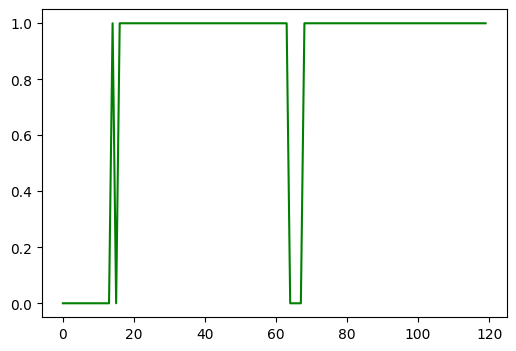

In [4]:
import matplotlib.pyplot as plt
import pickle

with open("cscg_lapwise_train10232.pkl", 'rb') as f:
    chmm2: CHMM = pickle.load(f)

state = chmm2.decode(x_test, a_test)[1]
reorder = np.argsort(state)
nll_per_prediction = chmm2.bps(
    x_test, a_test
)

mat = np.zeros((900, len(state)))
for i in range(len(state)):
    mat[state[i], i] = nll_per_prediction[i]

state_perf = chmm2.decode(x_perf, a_perf)[1]
state_perf_reorder = np.argsort(state_perf)
nll_per_prediction_perf = chmm2.bps(
    x_perf, a_perf
)

mat2 = np.zeros((900, len(state_perf)))
for i in range(len(state_perf)):
    mat2[state_perf[i], i] = nll_per_prediction_perf[i]

plt.show()
is_retrieve = np.zeros_like(state, dtype=np.int64)
for i in range(1, len(state)):
    node_i = res_test['Nodes'][i]-1
    try:
        idx = np.where(CP_DSP1[0]-1 == node_i)[0][0]
    except:
        continue
    
    retrieved_state = state_perf[idx]
    real_state = state[i]
    if retrieved_state == real_state:
        is_retrieve[i] = 1

def identified_retrieval(state, retrieved_state):
    if retrieved_state == state:
        return 1
    else:
        return 0

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.plot(np.arange(len(state)), is_retrieve, label="Is Retrieve", color="green")

# Step-wise Retrieval

In [ ]:
import copy as cp

chmm3 = cp.deepcopy(chmm2)
for i in range(len(x_test)):
    chmm3.learn_em_T(x_test[:i+1], a_test[i:i+1], n_iter=100, term_early=False)
state = chmm3.decode(x_test, a_test)[1]

 37%|███▋      | 37/100 [00:00<00:00, 119.30it/s, train_bps=0.162]

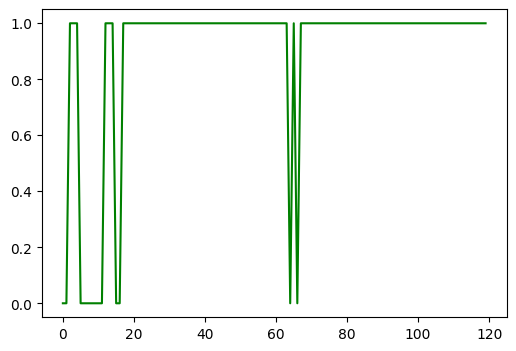

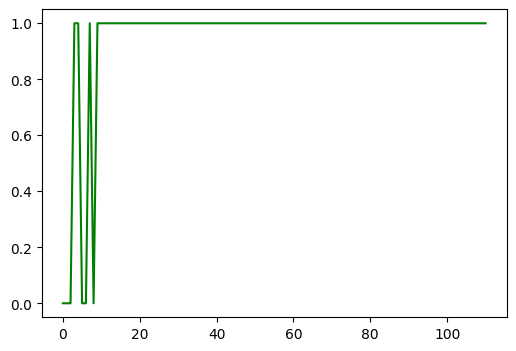

In [33]:
is_retrieve = np.zeros_like(state, dtype=np.int64)
for i in range(1, len(state)):
    node_i = res_test['Nodes'][i]-1
    try:
        idx = np.where(CP_DSP1[0]-1 == node_i)[0][0]
    except:
        continue
    
    retrieved_state = state_perf[idx]
    real_state = state[i]
    if retrieved_state == real_state:
        is_retrieve[i] = 1
        
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.plot(np.arange(len(state)), is_retrieve, label="Is Retrieve", color="green")
plt.show()

state_perf2 = chmm3.decode(x_perf, a_perf)[1]

is_retrieve = np.where(state_perf2 - state_perf == 0, 1, 0)
        
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.plot(np.arange(len(state_perf2)), is_retrieve, label="Is Retrieve", color="green")
plt.show()